# Aircraft Take-Off Weight Prediction using Regression Models

This project explores the use of different regression algorithms to estimate aircraft take-off weight based on operational and flight-related parameters.

The goal is to compare different linear regression approaches and evaluate their performance for engineering-related prediction tasks.

Implemented models:
- Linear Regression
- Ridge Regression
- Lasso Regression

Model Evaluation:

The models are evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Cross-validation scores

The results allow comparison of model performance and generalization capability.

The models are implemented in Python using Scikit-learn and evaluated using cross-validation.

Technologies used:
- Python
- Scikit-learn
- Pandas
- Matplotlib / Seaborn

## Dataset Description

The dataset contains flight and airport-related operational parameters used to estimate aircraft take-off weight.

Input features include:
- Numerical variables describing flight parameters
- Categorical variables related to airport information

The dataset is preprocessed using a pipeline that handles:
- numerical scaling
- categorical encoding
- train-test splitting

## Machine Learning Pipeline

To ensure consistent preprocessing and model training, a machine learning pipeline is implemented using Scikit-learn.

The pipeline includes:
- feature preprocessing
- model training
- cross-validation
- evaluation metrics

This structure allows efficient comparison of different regression models.

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Functions

In [2]:
def build_dataset(
    csv_path: str,
    target: str,
    numerical_features: list,
    categorical_features: list,
    date_col: str = "date",
    make_time_features: bool = True
):
    """Load data, (optionally) engineer time features, drop missing required cols, return df_model, X, y."""
    df = pd.read_csv(csv_path)

    if make_time_features:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df["month"] = df[date_col].dt.month
        df["day_of_week"] = df[date_col].dt.dayofweek

    required_cols = numerical_features + categorical_features + [target]
    df_model = df.dropna(subset=required_cols).copy()

    X = df_model[numerical_features + categorical_features]
    y = df_model[target]
    return df_model, X, y


def split_data(X, y, test_size=0.2, random_state=42):
    """Consistent train/test split."""
    return train_test_split(X, y, test_size=test_size, random_state=random_state)


def build_preprocessor(numerical_features: list, categorical_features: list):
    """Single source of truth for preprocessing."""
    return ColumnTransformer(
        transformers=[
            ("num", "passthrough", numerical_features),
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
        ]
    )


def build_pipeline(preprocessor, regressor):
    """Consistent pipeline structure for all models."""
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler(with_mean=False)),
        ("regressor", regressor),
    ])


def get_feature_names(fitted_pipeline, numerical_features, categorical_features):
    """Get post-encoding feature names (safe, consistent)."""
    cat_names = fitted_pipeline.named_steps["preprocessor"] \
        .named_transformers_["cat"].get_feature_names_out(categorical_features).tolist()
    return numerical_features + cat_names


def evaluate_regression(model, X_train, y_train, X_test, y_test, X_all=None, y_all=None, cv=5):
    """Compute train/test MAE, RMSE, R², and optionally CV R²."""
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    metrics = {
        "train_mae": mean_absolute_error(y_train, y_pred_train),
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "train_r2": r2_score(y_train, y_pred_train),
        "test_mae": mean_absolute_error(y_test, y_pred_test),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "test_r2": r2_score(y_test, y_pred_test),
        "y_pred_test": y_pred_test,  # for plotting
        "residuals_test": (y_test - y_pred_test),
    }

    if X_all is not None and y_all is not None:
        cv_scores = cross_val_score(model, X_all, y_all, cv=cv, scoring="r2", n_jobs=-1)
        metrics["cv_r2_mean"] = cv_scores.mean()
        metrics["cv_r2_std"] = cv_scores.std()

    return metrics


# Stores colors ONLY for features that appear in ANY top-20 plot
TOP20_COLOR_MAP = {}

def _distinct_color_pool():
    """A pool of high-contrast colors (repeatable)."""
    pool = []
    for name in ["tab20", "tab20b", "tab20c", "Set3", "Paired", "Dark2", "Accent"]:
        pool += sns.color_palette(name)
    return pool

_COLOR_POOL = _distinct_color_pool()


def assign_top20_colors(top_features, color_map=TOP20_COLOR_MAP, color_pool=_COLOR_POOL):
    """
    Ensure each feature in `top_features` has a stable color in `color_map`,
    assigning new colors only as needed. Does NOT touch the other 380 features.
    """
    # Assign colors to new features (stable across models once assigned)
    used_colors_global = set(tuple(c) for c in color_map.values())

    pool_idx = 0
    for f in top_features:
        if f not in color_map:
            # Find the next unused color in the pool
            while pool_idx < len(color_pool) and tuple(color_pool[pool_idx]) in used_colors_global:
                pool_idx += 1
            # If pool exhausted, just cycle (rare)
            c = color_pool[pool_idx % len(color_pool)]
            color_map[f] = c
            used_colors_global.add(tuple(c))
            pool_idx += 1

    # Return palette dict just for this plot (seaborn wants dict when using hue)
    return {f: color_map[f] for f in top_features}


def plot_coef_bar_top20(feature_names, coefs, title="Top coefficients", top_n=20, color_map=TOP20_COLOR_MAP):
    """
    Plots top_n coefficients with:
    - distinct colors within the chart
    - same feature keeps same color across models (if it ever appears in top_n)
    - no need to color all 380 features
    """
    coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
    coef_df["abs"] = coef_df["coef"].abs()
    top = coef_df.sort_values("abs", ascending=False).head(top_n).copy()

    top_feats = top["feature"].tolist()
    palette = assign_top20_colors(top_feats, color_map=color_map)

    # Guarantee distinctness within the chart (just in case of accidental collision)
    used = set()
    for f in top_feats:
        c = tuple(palette[f])
        if c in used:
            # pick any color from pool not already used in this plot
            for candidate in _COLOR_POOL:
                tc = tuple(candidate)
                if tc not in used:
                    palette[f] = candidate
                    c = tc
                    break
        used.add(c)

    plt.figure(figsize=(8, 6))
    ax = sns.barplot(
        data=top,
        x="coef",
        y="feature",
        hue="feature",      # avoids seaborn deprecation + enables per-bar palette
        palette=palette,    # dict feature->color (only for top 20)
        dodge=False,
        legend=False
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("Feature")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_diagnostics(y_test, y_pred_test, residuals, title_prefix="Model"):
    """Core regression diagnostic plots."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    plt.suptitle(f"{title_prefix} — Diagnostics", fontsize=14)

    # Predicted vs Actual
    axes[0, 0].scatter(y_test, y_pred_test, alpha=0.3)
    minv, maxv = y_test.min(), y_test.max()
    axes[0, 0].plot([minv, maxv], [minv, maxv], "r--")
    axes[0, 0].set_title("Predicted vs Actual")
    axes[0, 0].set_xlabel("Actual TOW [kg]")
    axes[0, 0].set_ylabel("Predicted TOW [kg]")

    # Residuals vs Predicted
    axes[0, 1].scatter(y_pred_test, residuals, alpha=0.3)
    axes[0, 1].axhline(0, color="r", ls="--")
    axes[0, 1].set_title("Residuals vs Predicted")
    axes[0, 1].set_xlabel("Predicted TOW [kg]")
    axes[0, 1].set_ylabel("Residual [kg]")

    # Residual histogram
    axes[1, 0].hist(residuals, bins=100)
    axes[1, 0].axvline(0, color="r", ls="--")
    axes[1, 0].set_title("Residual Distribution")
    axes[1, 0].set_xlabel("Residual [kg]")
    axes[1, 0].set_ylabel("Count")

    # Q-Q plot
    stats.probplot(residuals, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title("Q–Q Plot (Residuals)")

    plt.tight_layout()
    plt.show()


def plot_learning_curves(estimator, X_train, y_train, title_prefix="Model", cv=5, points=8):
    """Learning curves for R² and RMSE."""
    train_sizes = np.linspace(0.1, 1.0, points)

    # R² curve
    sizes, train_r2, val_r2 = learning_curve(
        estimator=estimator,
        X=X_train, y=y_train,
        train_sizes=train_sizes,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )
    plt.figure(figsize=(7, 5))
    plt.plot(sizes, train_r2.mean(axis=1), marker="o", label="Train R²")
    plt.plot(sizes, val_r2.mean(axis=1), marker="o", label="Validation R²")
    plt.fill_between(sizes, train_r2.mean(axis=1)-train_r2.std(axis=1), train_r2.mean(axis=1)+train_r2.std(axis=1), alpha=0.2)
    plt.fill_between(sizes, val_r2.mean(axis=1)-val_r2.std(axis=1), val_r2.mean(axis=1)+val_r2.std(axis=1), alpha=0.2)
    plt.title(f"{title_prefix} — Learning Curve (R²)")
    plt.xlabel("Training set size")
    plt.ylabel("R²")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # RMSE curve (via negative MSE)
    sizes, train_mse, val_mse = learning_curve(
        estimator=estimator,
        X=X_train, y=y_train,
        train_sizes=train_sizes,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
    train_rmse = np.sqrt(-train_mse.mean(axis=1))
    val_rmse = np.sqrt(-val_mse.mean(axis=1))

    plt.figure(figsize=(7, 5))
    plt.plot(sizes, train_rmse, marker="o", label="Train RMSE")
    plt.plot(sizes, val_rmse, marker="o", label="Validation RMSE")
    plt.title(f"{title_prefix} — Learning Curve (RMSE)")
    plt.xlabel("Training set size")
    plt.ylabel("RMSE [kg]")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Global configuration + build consistent data/split/preprocessor

In [3]:
# ---- CONFIG (single source of truth) ----
CSV_PATH = "flight_list_with_airport_data_km.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5

target = "tow [kg]"

numerical_features = [
    "flight_duration [min]",
    "flown_distance [km]",
    "taxiout_time [min]",
    "adep_elevation_km",
    "ades_elevation_km",
    "month",
    "day_of_week"
]

categorical_features = [
    "aircraft_type",
    "wtc",
    "adep",
    "ades"
]

# ---- BUILD DATA ----
df_model, X, y = build_dataset(
    csv_path=CSV_PATH,
    target=target,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    make_time_features=True
)

# ---- SPLIT ----
X_train, X_test, y_train, y_test = split_data(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# ---- PREPROCESSOR ----
preprocessor = build_preprocessor(numerical_features, categorical_features)

print("Data ready.")
print("Rows:", len(df_model))
print("Train size:", len(X_train), "| Test size:", len(X_test))


Data ready.
Rows: 525731
Train size: 420584 | Test size: 105147


# Linear Regression Baseline

Linear regression is used as a baseline model to evaluate the predictive capability of the dataset.

It assumes a linear relationship between the input variables and the target variable (aircraft take-off weight).

## Linear Regression Algorithm

C:\Users\meria\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Linear:
TRAIN -> MAE: 4417 | RMSE: 7115 | R²: 0.982
TEST  -> MAE: 4414 | RMSE: 7093 | R²: 0.982
CV R²: 0.982 ± 0.001


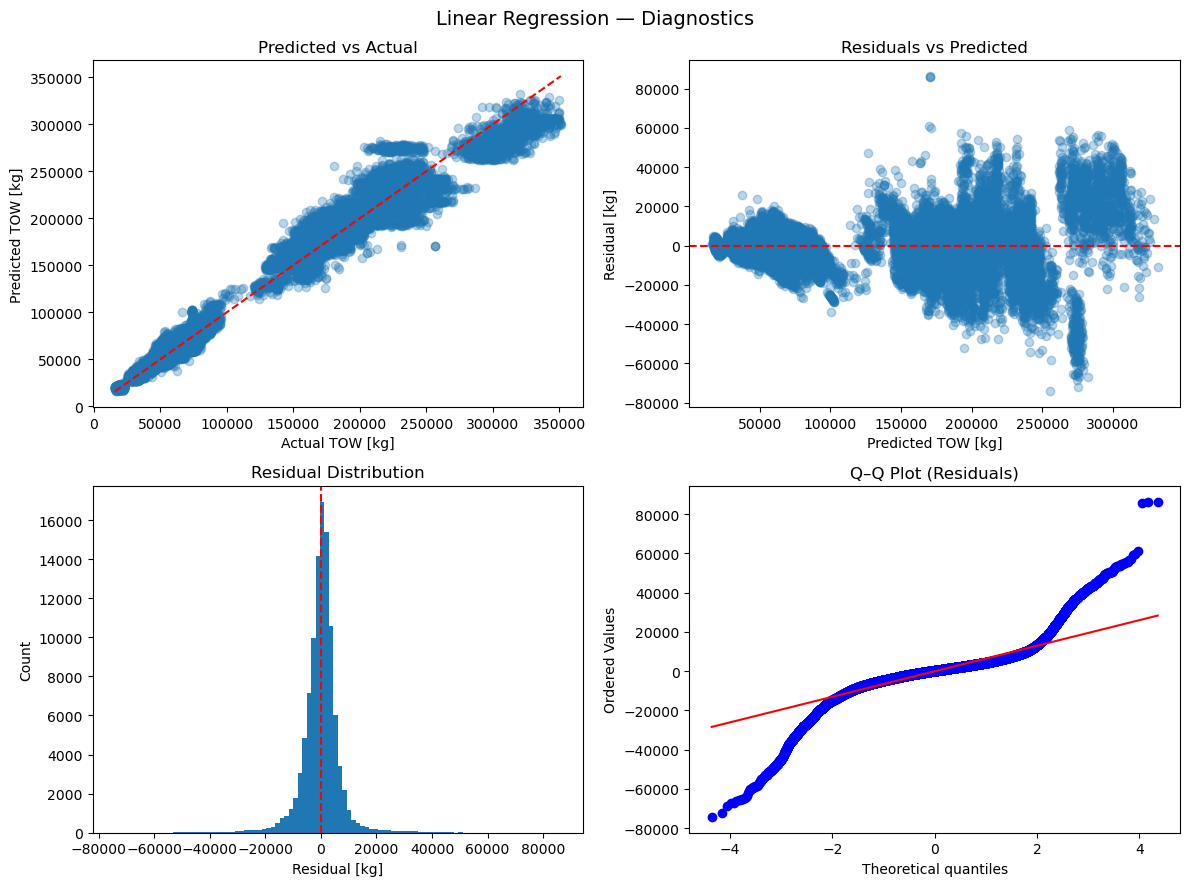

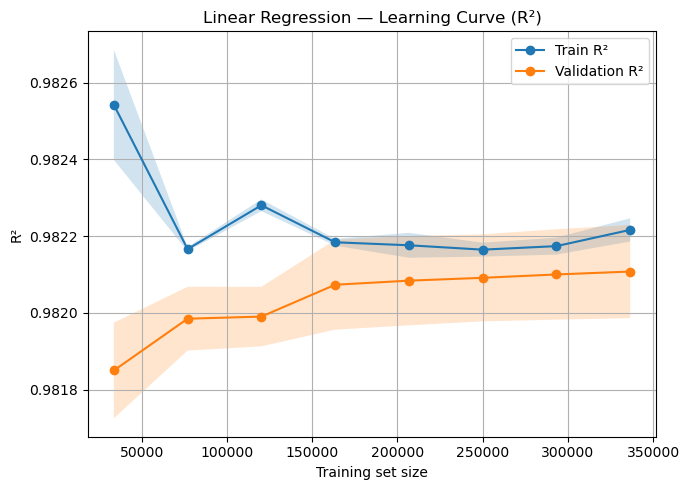

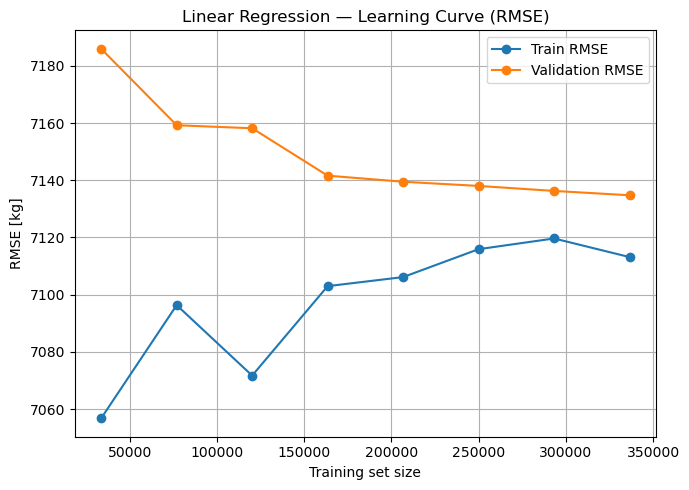

C:\Users\meria\AppData\Local\Temp\ipykernel_12120\957003038.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x="coef", y="feature", palette=palette)


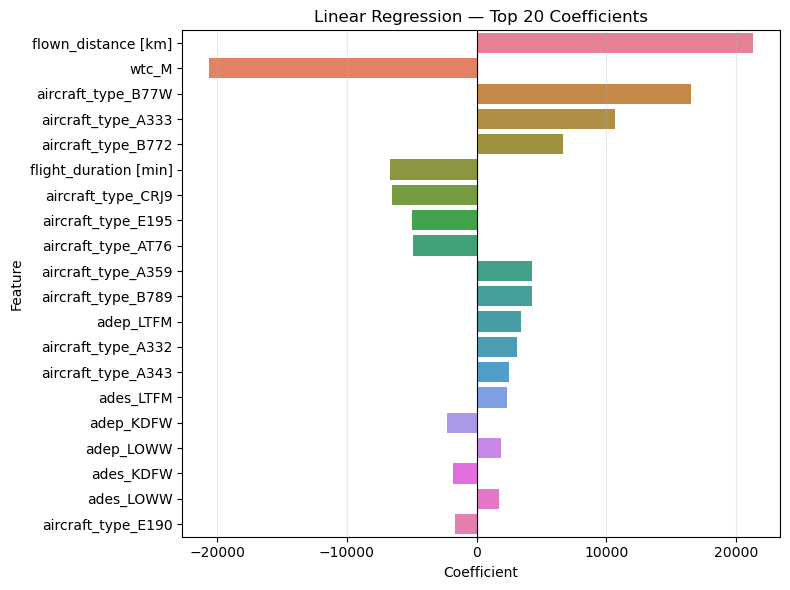

In [25]:
linear_pipeline = build_pipeline(preprocessor, LinearRegression())
linear_pipeline.fit(X_train, y_train)

lin_metrics = evaluate_regression(
    linear_pipeline,
    X_train, y_train,
    X_test, y_test,
    X_all=X, y_all=y,
    cv=CV_FOLDS
)

print("Linear:")
print(f"TRAIN -> MAE: {lin_metrics['train_mae']:.0f} | RMSE: {lin_metrics['train_rmse']:.0f} | R²: {lin_metrics['train_r2']:.3f}")
print(f"TEST  -> MAE: {lin_metrics['test_mae']:.0f} | RMSE: {lin_metrics['test_rmse']:.0f} | R²: {lin_metrics['test_r2']:.3f}")
print(f"CV R²: {lin_metrics['cv_r2_mean']:.3f} ± {lin_metrics['cv_r2_std']:.3f}")

# Diagnostics
plot_diagnostics(
    y_test,
    lin_metrics["y_pred_test"],
    lin_metrics["residuals_test"],
    title_prefix="Linear Regression"
)

# Learning curves
plot_learning_curves(
    linear_pipeline,
    X_train,
    y_train,
    title_prefix="Linear Regression",
    cv=CV_FOLDS
)

# Coefficients
feature_names = get_feature_names(
    linear_pipeline,
    numerical_features,
    categorical_features
)

linear_coefs = linear_pipeline.named_steps["regressor"].coef_

plot_coef_bar(
    feature_names,
    linear_coefs,
    title="Linear Regression — Top 20 Coefficients"
)


## Error in each band

In [ ]:
import pandas as pd
import numpy as np

# Build dataframe from test predictions
band_df = pd.DataFrame({
    "actual_tow": y_test.values,
    "predicted_tow": lin_metrics["y_pred_test"]
})

# Residuals
band_df["residual"] = band_df["actual_tow"] - band_df["predicted_tow"]
band_df["abs_residual"] = np.abs(band_df["residual"])
band_df["sq_residual"] = band_df["residual"]**2

# -----------------------------------------
# Define 3 bands using quantiles
# -----------------------------------------
band_df["tow_band"] = pd.qcut(
    band_df["actual_tow"],
    q=3,
    labels=["Band 1 (Low)", "Band 2 (Mid)", "Band 3 (High)"]
)

# -----------------------------------------
# Compute metrics per band
# -----------------------------------------
band_metrics = band_df.groupby("tow_band").agg(
    MAE=("abs_residual", "mean"),
    RMSE=("sq_residual", lambda x: np.sqrt(x.mean())),
    Mean_Residual=("residual", "mean"),
    Count=("residual", "count")
)

print(band_metrics.round(1))

band_metrics[["MAE", "RMSE"]].plot(kind="bar", figsize=(6,4))
plt.ylabel("Error [kg]")
plt.title("Prediction Error by TOW Band")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()


# L2-Regularization: Ridge  Algorithm

Best alpha (Ridge): 1.0


C:\Users\meria\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Ridge:
TRAIN -> MAE: 4416 | RMSE: 7115 | R²: 0.982
TEST  -> MAE: 4413 | RMSE: 7092 | R²: 0.982
CV R²: 0.982 ± 0.001


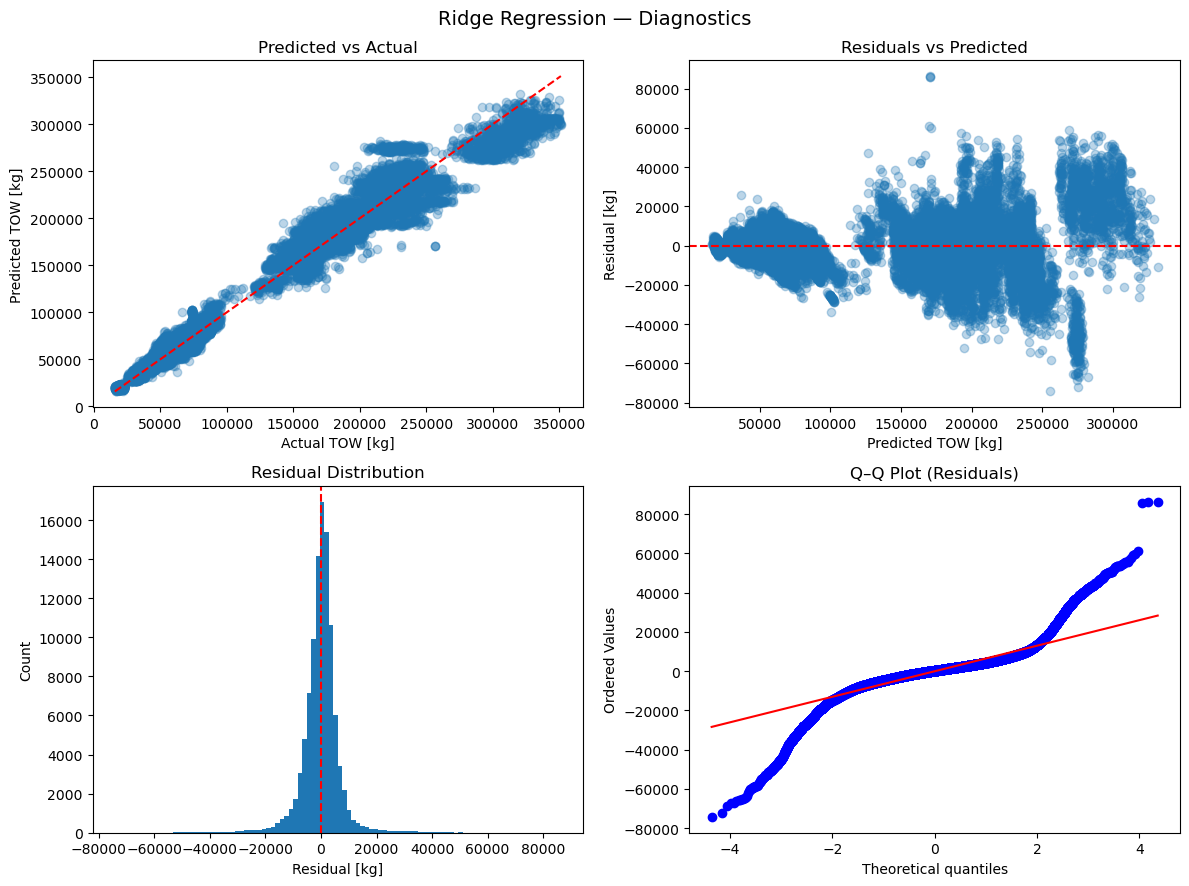

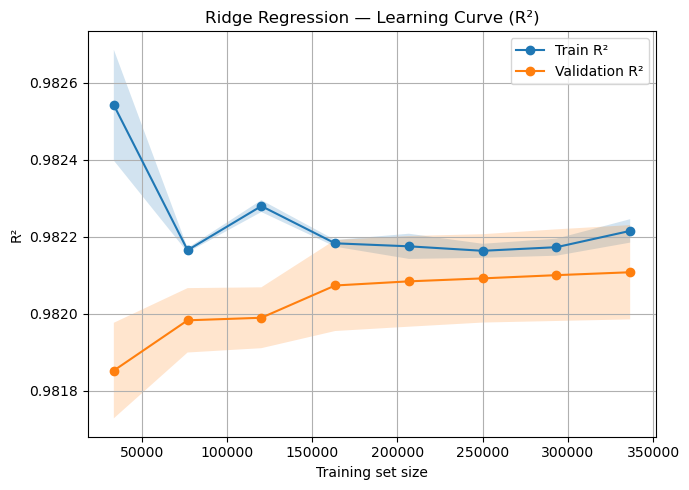

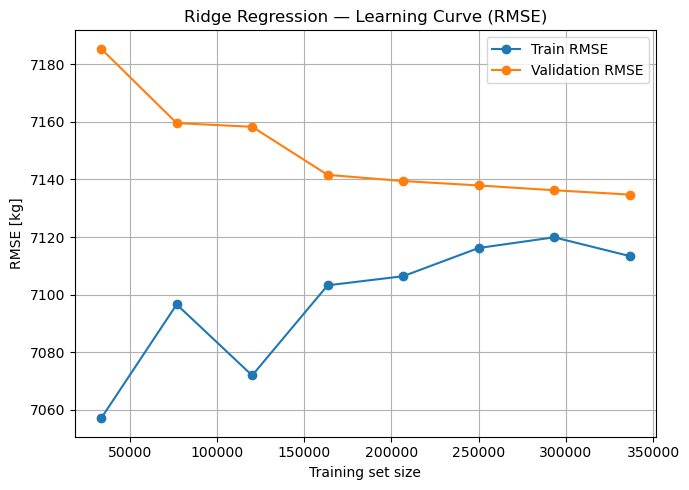

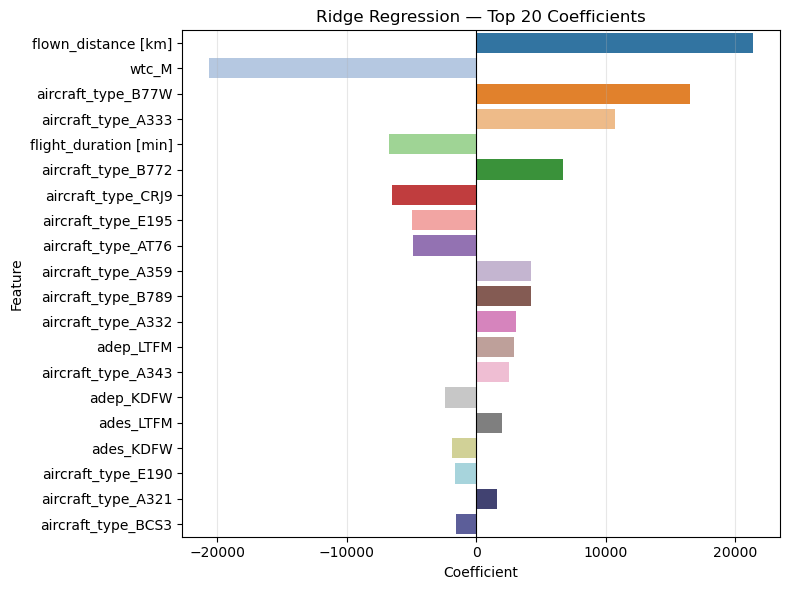

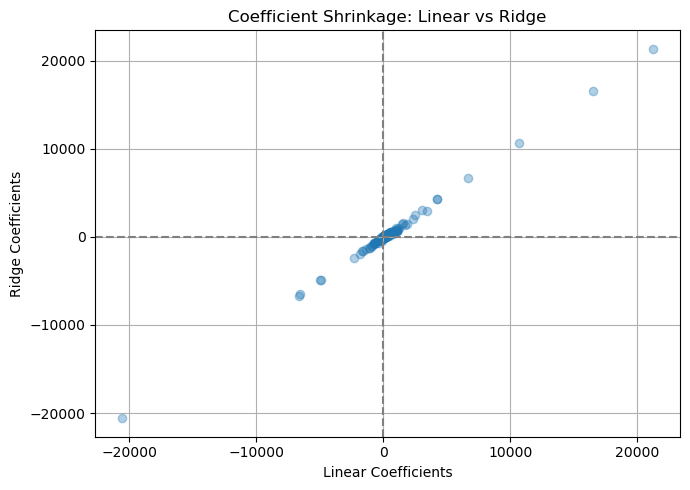


Top 20 coefficients — Linear vs Ridge:



,feature,Linear_coef,Ridge_coef,Shrinkage_ratio
1,flown_distance [km],21277.559051,21350.750867,1.003440
36,wtc_M,-20585.136464,-20587.108328,1.000096
26,aircraft_type_B77W,16535.240806,16536.386560,1.000069
13,aircraft_type_A333,10687.664698,10691.063936,1.000318
24,aircraft_type_B772,6683.058705,6682.273224,0.999882
0,flight_duration [min],-6659.624662,-6737.579233,1.011706
32,aircraft_type_CRJ9,-6533.008512,-6528.475883,0.999306
34,aircraft_type_E195,-4955.488107,-4950.070211,0.998907
16,aircraft_type_AT76,-4893.144437,-4890.413686,0.999442
15,aircraft_type_A359,4253.070399,4253.434816,1.000086


In [32]:
ridge_base = build_pipeline(preprocessor, Ridge())

param_grid = {"regressor__alpha": np.logspace(-2, 4, 10)}

grid = GridSearchCV(ridge_base, param_grid, cv=CV_FOLDS, scoring="neg_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)

ridge_pipeline = grid.best_estimator_
best_alpha = grid.best_params_["regressor__alpha"]
print("Best alpha (Ridge):", best_alpha)

ridge_metrics = evaluate_regression(ridge_pipeline, X_train, y_train, X_test, y_test, X_all=X, y_all=y, cv=CV_FOLDS)



print("Ridge:")
print(f"TRAIN -> MAE: {ridge_metrics['train_mae']:.0f} | RMSE: {ridge_metrics['train_rmse']:.0f} | R²: {ridge_metrics['train_r2']:.3f}")
print(f"TEST  -> MAE: {ridge_metrics['test_mae']:.0f} | RMSE: {ridge_metrics['test_rmse']:.0f} | R²: {ridge_metrics['test_r2']:.3f}")
print(f"CV R²: {ridge_metrics['cv_r2_mean']:.3f} ± {ridge_metrics['cv_r2_std']:.3f}")



# Diagnostics + learning curves
plot_diagnostics(y_test, ridge_metrics["y_pred_test"], ridge_metrics["residuals_test"], title_prefix="Ridge Regression")
plot_learning_curves(ridge_pipeline, X_train, y_train, title_prefix="Ridge Regression", cv=CV_FOLDS)

# Ridge coefficients bar chart
ridge_coefs = ridge_pipeline.named_steps["regressor"].coef_
#plot_coef_bar(feature_names, ridge_coefs, title="Ridge Regression — Top 20 Coefficients")




ridge_coefs = ridge_pipeline.named_steps["regressor"].coef_
plot_coef_bar_top20(feature_names, ridge_coefs, title="Ridge Regression — Top 20 Coefficients")


# Coefficient shrinkage scatter (Linear vs Ridge)
plt.figure(figsize=(7, 5))
plt.scatter(linear_coefs, ridge_coefs, alpha=0.35)
plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Linear Coefficients")
plt.ylabel("Ridge Coefficients")
plt.title("Coefficient Shrinkage: Linear vs Ridge")
plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================
# Linear vs Ridge coefficient comparison table
# =====================================
coef_table = pd.DataFrame({
    "feature": feature_names,
    "Linear_coef": linear_coefs,
    "Ridge_coef": ridge_coefs
})

coef_table["Linear_abs"] = coef_table["Linear_coef"].abs()
coef_table["Ridge_abs"] = coef_table["Ridge_coef"].abs()
coef_table["Shrinkage_ratio"] = coef_table["Ridge_abs"] / coef_table["Linear_abs"]

# Sort by absolute Linear coefficient
coef_table_sorted = coef_table.sort_values("Linear_abs", ascending=False)

# Display top 20
print("\nTop 20 coefficients — Linear vs Ridge:\n")
display(
    coef_table_sorted[
        ["feature", "Linear_coef", "Ridge_coef", "Shrinkage_ratio"]
    ].head(20)
)



# L2-Regularization: Lasso Algorithm

C:\Users\meria\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


Best alpha (LassoCV): 49.12910177150259


C:\Users\meria\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Lasso performance:
TRAIN -> MAE: 4371 | RMSE: 7214 | R²: 0.982
TEST  -> MAE: 4360 | RMSE: 7187 | R²: 0.982
CV R²: 0.981 ± 0.001
Zeroed coefficients (Lasso): 638 / 870 (73.3%)


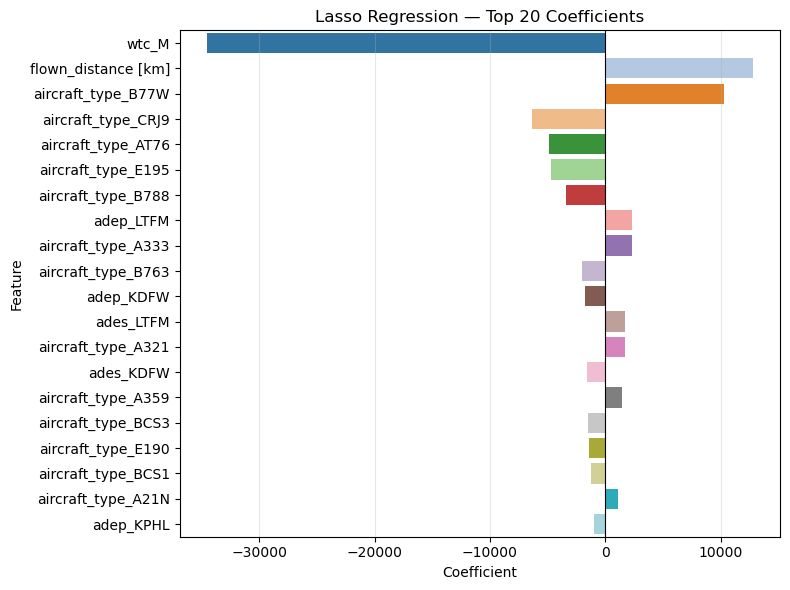

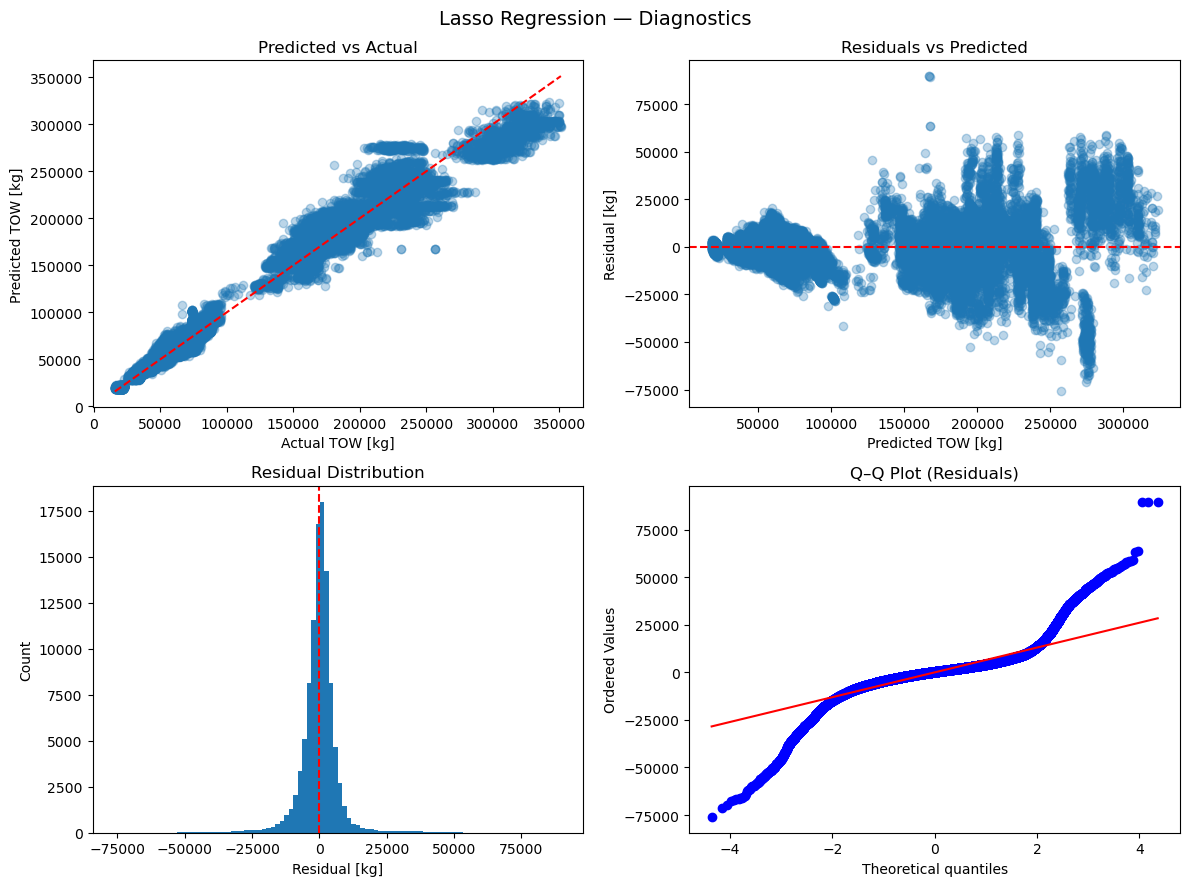

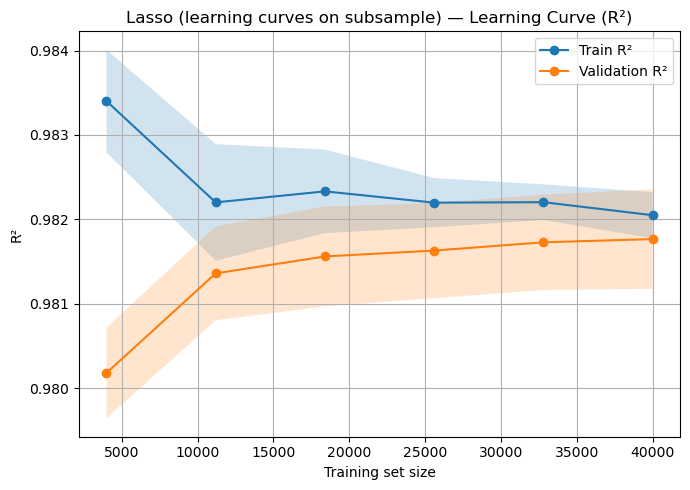

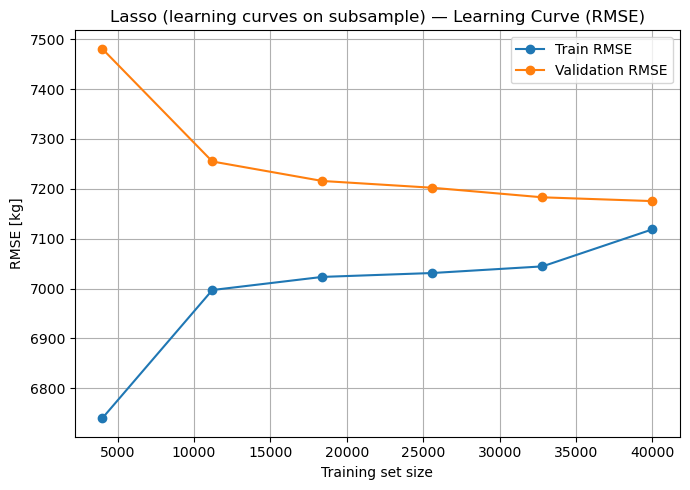

In [5]:
from sklearn.linear_model import Lasso, LassoCV
import numpy as np

# ------------------------------------------------------------
# 2) Tune alpha on a SUBSAMPLE of the TRAIN SET (same features!)
# ------------------------------------------------------------
SUBSAMPLE_N = 60_000
X_train_sub = X_train.sample(n=min(SUBSAMPLE_N, len(X_train)), random_state=RANDOM_STATE)
y_train_sub = y_train.loc[X_train_sub.index]

# ------------------------------------------------------------
# 2b) LassoCV chooses its OWN alpha grid (remove `alphas=...`)
#     Speed knobs: n_alphas, eps, cv
# ------------------------------------------------------------
lasso_cv = LassoCV(
    # alphas is intentionally NOT provided -> LassoCV chooses its own grid
    n_alphas=30,        # default 100; smaller = faster
    eps=1e-3,           # alpha_min = alpha_max * eps; larger eps = narrower range = faster
    cv=3,               # faster than 5 on big data; still good for alpha selection
    max_iter=50_000,
    tol=1e-4,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

lasso_tune_pipeline = build_pipeline(preprocessor, lasso_cv)
lasso_tune_pipeline.fit(X_train_sub, y_train_sub)

best_alpha_lasso = lasso_tune_pipeline.named_steps["regressor"].alpha_
print(f"Best alpha (LassoCV): {best_alpha_lasso}")

# ------------------------------------------------------------
# 3) Fit final Lasso ON FULL TRAIN SET (same features!)
# ------------------------------------------------------------
lasso_pipeline = build_pipeline(
    preprocessor,
    Lasso(alpha=best_alpha_lasso, max_iter=100_000, tol=1e-4)
)

lasso_pipeline.fit(X_train, y_train)

# ------------------------------------------------------------
# 4) Evaluate exactly like Linear/Ridge
# ------------------------------------------------------------
lasso_metrics = evaluate_regression(
    lasso_pipeline,
    X_train, y_train,
    X_test, y_test,
    X_all=X, y_all=y,
    cv=CV_FOLDS
)

print("\nLasso performance:")
print(f"TRAIN -> MAE: {lasso_metrics['train_mae']:.0f} | RMSE: {lasso_metrics['train_rmse']:.0f} | R²: {lasso_metrics['train_r2']:.3f}")
print(f"TEST  -> MAE: {lasso_metrics['test_mae']:.0f} | RMSE: {lasso_metrics['test_rmse']:.0f} | R²: {lasso_metrics['test_r2']:.3f}")
print(f"CV R²: {lasso_metrics['cv_r2_mean']:.3f} ± {lasso_metrics['cv_r2_std']:.3f}")

# ------------------------------------------------------------
# 5) Sparsity (Lasso-specific insight)
# ------------------------------------------------------------
lasso_coefs = lasso_pipeline.named_steps["regressor"].coef_
n_zero = (np.abs(lasso_coefs) < 1e-8).sum()
n_total = len(lasso_coefs)
print(f"Zeroed coefficients (Lasso): {n_zero} / {n_total} ({100*n_zero/n_total:.1f}%)")

# ------------------------------------------------------------
# 6) Coefficients bar chart + diagnostics + learning curves
# ------------------------------------------------------------
lasso_feature_names = get_feature_names(lasso_pipeline, numerical_features, categorical_features)

# Use your plotting function name (you previously used plot_coef_bar / plot_coef_bar_top20)
plot_coef_bar_top20(
    lasso_feature_names,
    lasso_coefs,
    title="Lasso Regression — Top 20 Coefficients",
    top_n=20
)

plot_diagnostics(
    y_test,
    lasso_metrics["y_pred_test"],
    lasso_metrics["residuals_test"],
    title_prefix="Lasso Regression"
)

plot_learning_curves(
    lasso_pipeline,
    X_train_sub,
    y_train_sub,
    title_prefix="Lasso (learning curves on subsample)",
    cv=3,       # match the faster CV used above
    points=6
)


# Models Comparison

In [ ]:
from sklearn.exceptions import ConvergenceWarning
import warnings

# Refit with very strict settings once and compare coefficient stability
strict_lasso_pipeline = build_pipeline(
    preprocessor,
    Lasso(alpha=best_alpha_lasso, max_iter=200000, tol=1e-6)
)
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always", ConvergenceWarning)
    strict_lasso_pipeline.fit(X_train, y_train)
    print("Convergence warnings:", [type(x.message).__name__ for x in w])

coefs_loose = lasso_pipeline.named_steps["regressor"].coef_
coefs_strict = strict_lasso_pipeline.named_steps["regressor"].coef_

print("Max abs coef diff (loose vs strict):", np.max(np.abs(coefs_loose - coefs_strict)))


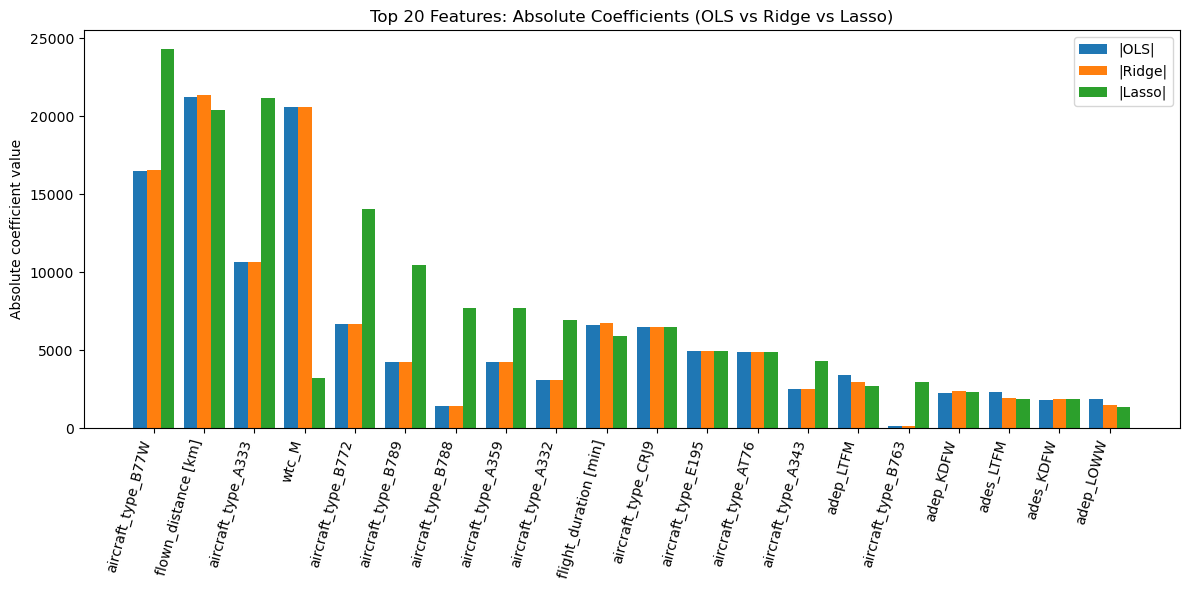

In [35]:


assert len(linear_coefs) == len(ridge_coefs) == len(lasso_coefs) == len(feature_names)

coef_compare_all = pd.DataFrame({
    "feature": feature_names,
    "OLS": linear_coefs,
    "Ridge": ridge_coefs,
    "Lasso": lasso_coefs
})

# Select top 20 features by maximum absolute coefficient across models
coef_compare_all["max_abs"] = coef_compare_all[["OLS", "Ridge", "Lasso"]].abs().max(axis=1)


top20 = coef_compare_all.sort_values("max_abs", ascending=False).head(20)

top20

top20_abs = top20.copy()
top20_abs["OLS"] = top20_abs["OLS"].abs()
top20_abs["Ridge"] = top20_abs["Ridge"].abs()
top20_abs["Lasso"] = top20_abs["Lasso"].abs()

labels = top20_abs["feature"].tolist()
x = np.arange(len(labels))
width = 0.27

plt.figure(figsize=(12, 6))
plt.bar(x - width, top20_abs["OLS"], width, label="|OLS|")
plt.bar(x,         top20_abs["Ridge"], width, label="|Ridge|")
plt.bar(x + width, top20_abs["Lasso"], width, label="|Lasso|")

plt.xticks(x, labels, rotation=75, ha="right")
plt.ylabel("Absolute coefficient value")
plt.title("Top 20 Features: Absolute Coefficients (OLS vs Ridge vs Lasso)")
plt.legend()
plt.tight_layout()
plt.show()



# Discussion

## MAE
*) OLS Train ≈ Test Indicates excellent generalization No sign of overfitting! *) Ridge Almost identical to Linear Regularization does not reduce MAE Confirms stability of baseline model *) Lasso Slightly lower MAE (≈5 kg difference) --> negligible

--> All three models achieve nearly identical performance!

--> Regularization does not improve absolute prediction accuracy. The baseline linear model already captures the dominant signal.

## RMSE

*) OLS
Train ≈ Test
No evidence of variance explosion
Error magnitude stable

*) Ridge
No reduction in RMSE
Indicates that large-error cases are not due to overfitting
Regularization not binding

*) Lasso
Same RMSE as Ridge and OLS
Sparse solution does not reduce large residuals


## MODEL AND PREDICTION ASSESSMENT

From all  metrics:
Train ≈ Test
CV mean ≈ Test
CV standard deviation very small

No overfitting is observed for any model. The regression problem is well-conditioned and data-dominated

Engineering-level takeaway:
(~7 tons RMSE) might be unacceptable in operational conditions.
May be more adequate for other types of use of the TOW


Although the absolute error magnitude (~7 tons RMSE) may appear large in an aviation context, the error is consistent across training, testing, and cross-validation, indicating that it reflects intrinsic operational variability rather than model deficiency.

## Model Comparison: Generalization performance 

### Models' Coefficients

High coefficients: Flown_distance, wtc_M, Aircraft type B77W (belonging to heavy class), A333 --> aircraft_type explains variance within the same WTC.
Hence:
WTC → coarse class effect
Aircraft type → fine-grained effect
Dominant: aircraft_type, wtc (should explain ~80% variance alone)
Lasso zeroed 638 out of 870 features, and re-ranked features weighting (f.e coefficient of flown_distance[km] dropped from ~22000 to ~12000)


### Predicted vs. Actual TOW [kg]

Wtc: either M or H, appears to be too coarse
The feature aircraft_type pushed the model to cover the patterns that wtc failed to capture --> Considering aircraft_type as well reshaped the clustering of the results --> more realistic
 

# Conclusion

1) 98% accuracy paired with MAE=4000kg and RMSE=7000kg and the absence of overfitting looks superficially impressive for aircraft TOW estimation
2) The model learns what we expect physically: longer routes and heavy-class wide-bodies increase TOW, while medium-class and regional types reduce it. Airport and mission effects appear as smaller upward or downward shift
3) Linear regression is an excellent global baseline, but it does not fully capture the complexity and variability of very heavy or extreme missions.
4) Ridge Regularization showed that the dataset is already not sensitive to correlated features (OLS must be sufficient)
5) Lasso further simplified the learning algorithm by eliminating 73% of the features

However
6) Residual benchmark signals:
Residuals are not Gaussian
Error variance is not constant → heteroscedasticity (uncertainties grow for heavy / long-haul flights )

--> the linear regression assumptions (normal, homoscedastic errors) are not fully satisfied



7) The data is heterogeneous: 
Different aircraft types (30 unique values)
Different flight ranges / missions 
Different airports and operational practices (up to 480 airports)
Existence of outliers and the class imbalance (unfair data size of heavy aircrafts) 
No explicit modeling of 
 Payload
 Weather / winds
 Detailed fuel policy
 Nonlinear fuel–distance relation
--> The linear learning is probably too simplified for this complexity, specially for the least represented class (heavy aircrafts)

Verdict:
Non-normal residuals and heteroscedasticity do not automatically invalidate linear regression as a predictive model.
Some regions (high TOW, ultra-long-haul) have larger uncertainty, however low-TOW aircrafts are well represented

8) TOW is a safety-critical number, deploying this model in operational planning aspects is a hard no. 
However, this estimator can still be useful for: 

Rough airline analytics & planning: 
Rough estimation of fuel burn, CO₂ emissions, and cost per flight
What if-analyses: What happens to fleet fuel use if average load factor goes up 5%?

Understand dependencies:

  See how TOW depends on route distance, aircraft type, airport pair. Helps decide: “Is this route better with A321neo or A330?”
  Spot weird patterns at specific airports (e.g. always unusually high TOW from a certain base → investigate local procedures

Estimator at the early stages of aircraft design


9) Future refinements

To addresse Heteroscedasticity : transformation of the target (e.g., log), additional nonlinear terms, or a different model family (e.g., robust regression or tree‑based methods)

To adresse class imbalance: class weighting 